# SupplyMind AI — Exploratory Data Analysis

## Objective

Perform distribution, outlier, relationship, correlation, and statistical
association analysis before finalizing the model feature contract.

In [12]:
# -------------------
# Imports
# -------------------

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from supplymind.features.predictions.domain.constants import (
    CATEGORICAL_FEATURES,
    NUMERICAL_FEATURES,
    TARGET_COLUMN,
)
from supplymind.features.predictions.ml.workflow import load_clean_syndelay

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [13]:
# -------------------
# Project configuration
# -------------------

DATASET_PATH = Path("../data/raw/syndelay/syndelay_v1.csv")
REPORT_ROOT = Path("../reports")

assert DATASET_PATH.exists(), (
    f"Dataset not found: {DATASET_PATH}"
)

In [14]:
from supplymind.features.predictions.ml.features import (
    engineer_features,
    feature_groups,
)
from supplymind.features.predictions.ml.feature_selection import (
    chi_square_categorical_report,
    mutual_information_report,
    numeric_correlation_report,
)

df = load_clean_syndelay(DATASET_PATH)
featured = engineer_features(df)
numerical_features, categorical_features = feature_groups()

## 1. Missing-value analysis

In [15]:
missing = (
    df.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .to_frame()
)

display(missing)

plot_missing = missing[missing["missing_pct"] > 0]

if not plot_missing.empty:
    plot_missing.sort_values("missing_pct").plot(
        kind="barh",
        figsize=(9, 6),
        legend=False,
        title="Missing Values by Column",
    )
    plt.xlabel("Missing (%)")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected.")

,missing_pct
payment_type,0.0
order_state,0.0
order_item_id,0.0
order_item_product_price,0.0
order_item_profit_ratio,0.0
order_item_quantity,0.0
sales,0.0
order_item_total_amount,0.0
order_profit_per_order,0.0
order_region,0.0


No missing values detected.


### Analysis

Missingness determines whether imputation is necessary. The production
preprocessing pipeline still includes safe imputers because future ERP data
may be less complete than the synthetic benchmark.

## 2. Numerical distributions

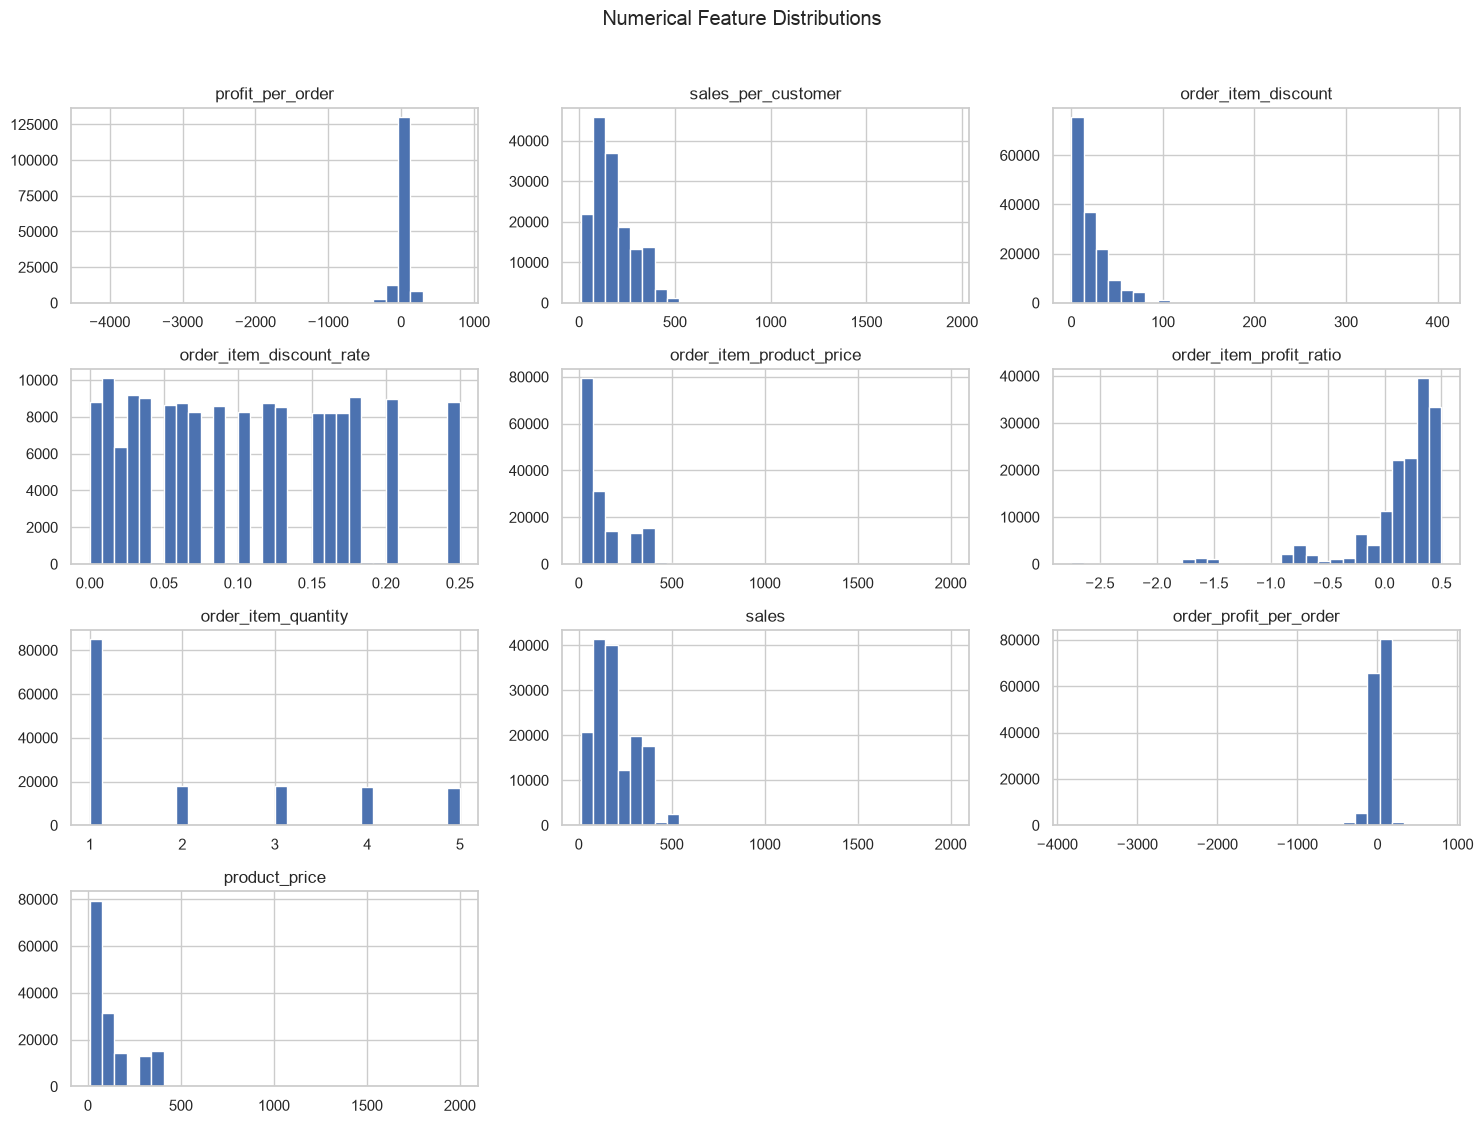

In [16]:
distribution_features = [
    "profit_per_order",
    "sales_per_customer",
    "order_item_discount",
    "order_item_discount_rate",
    "order_item_product_price",
    "order_item_profit_ratio",
    "order_item_quantity",
    "sales",
    "order_profit_per_order",
    "product_price",
]

df[distribution_features].hist(
    bins=30,
    figsize=(15, 11),
    layout=(4, 3),
)
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

### Analysis

These distributions reveal skew, discrete price/discount tiers, and unusually
extreme values. Tree-based models are naturally robust to monotonic scaling,
while Logistic Regression benefits from standardized numeric inputs.

Outliers should not be automatically removed: genuine extreme commercial
values can carry predictive signal.

## 3. Boxplots and outlier inspection

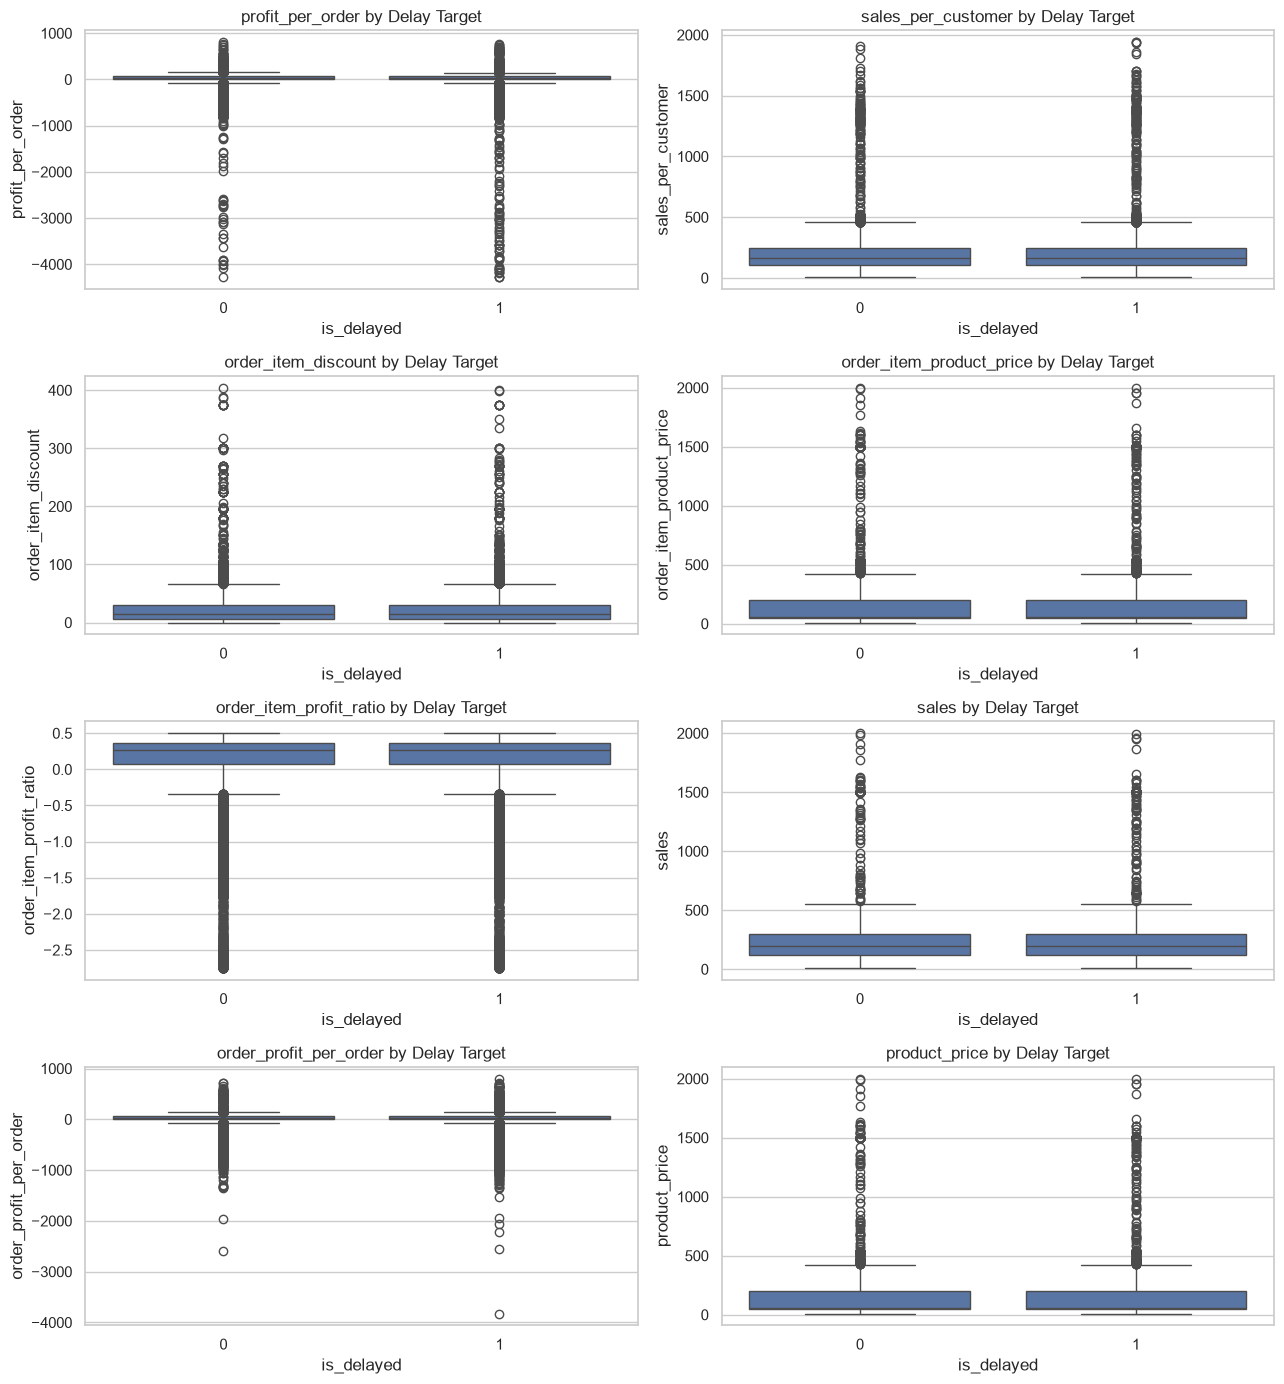

In [17]:
selected = [
    "profit_per_order",
    "sales_per_customer",
    "order_item_discount",
    "order_item_product_price",
    "order_item_profit_ratio",
    "sales",
    "order_profit_per_order",
    "product_price",
]

fig, axes = plt.subplots(4, 2, figsize=(13, 14))

for ax, column in zip(axes.flatten(), selected):
    sns.boxplot(
        data=df,
        x=TARGET_COLUMN,
        y=column,
        ax=ax,
    )
    ax.set_title(f"{column} by Delay Target")

plt.tight_layout()
plt.show()

### Analysis

The goal here is not to delete all statistical outliers. Instead, compare the
shape of each feature between delayed and not-delayed groups. Large overlap
indicates limited standalone discriminatory power; systematic shifts may still
be useful when combined with other features.

## 4. Pearson correlation matrix

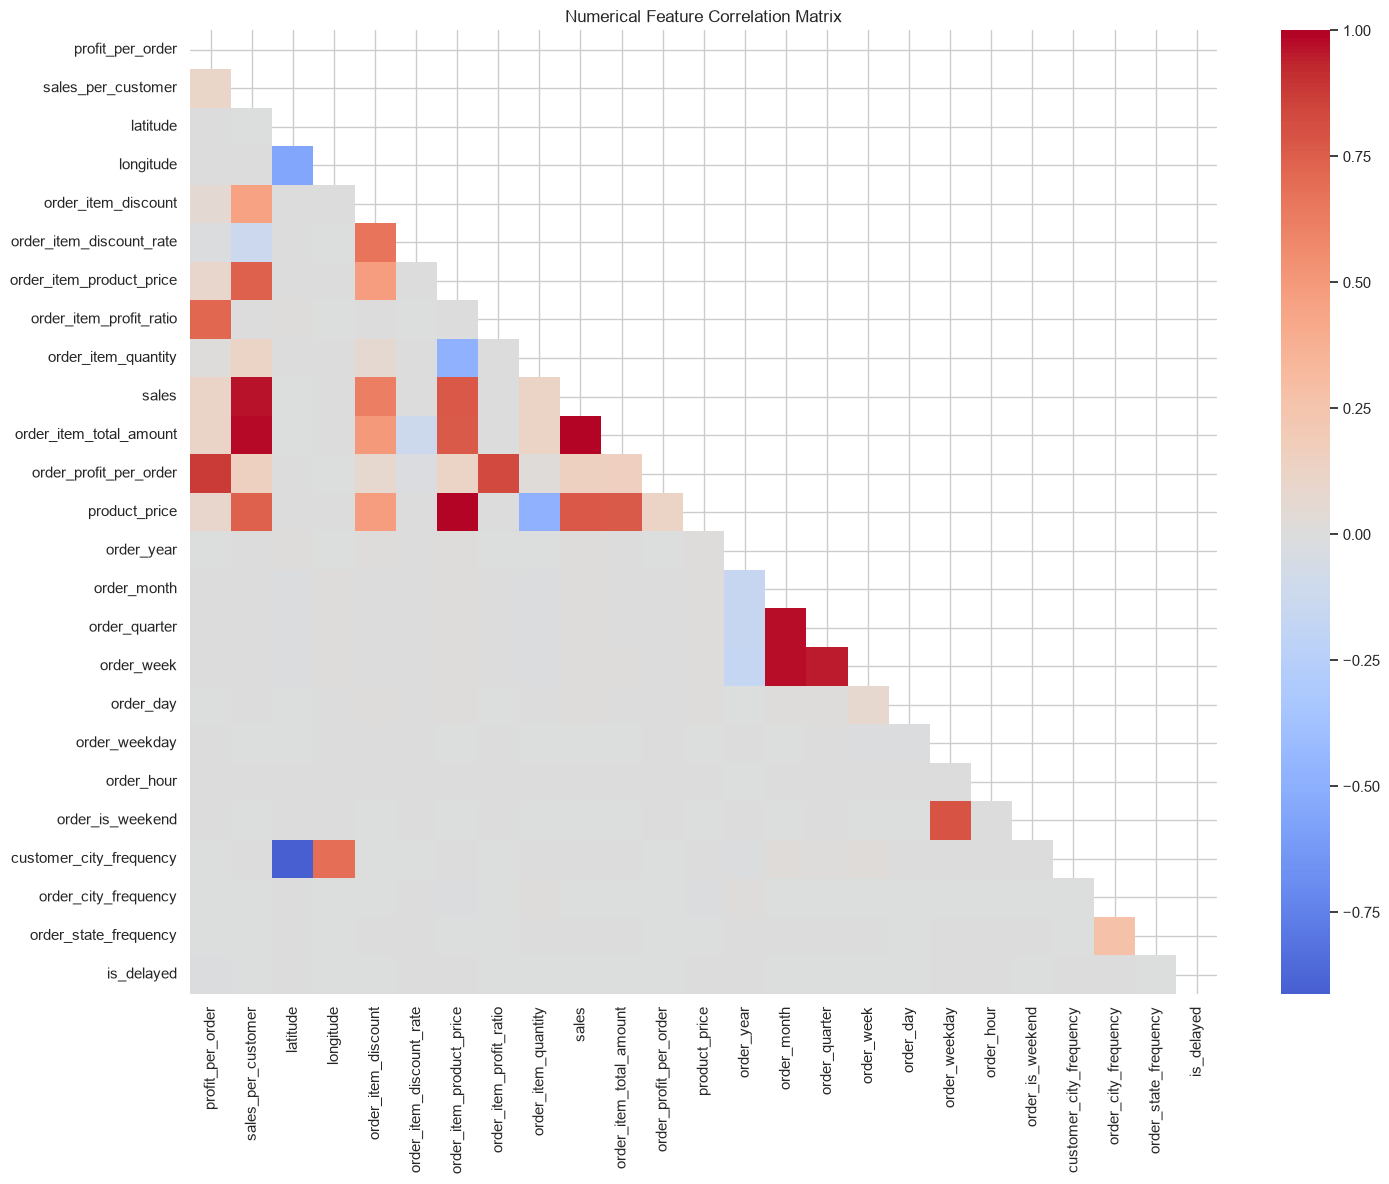

,correlation
profit_per_order,-0.008580
order_profit_per_order,-0.006619
order_hour,0.006173
order_year,0.003419
order_item_quantity,-0.003071
order_item_profit_ratio,-0.003047
order_item_discount_rate,0.003016
order_day,-0.002937
longitude,-0.002746
sales,-0.002589


In [18]:
correlation_columns = [
    c for c in numerical_features
    if c in featured.columns
] + [TARGET_COLUMN]

corr = featured[correlation_columns].corr(numeric_only=True)

plt.figure(figsize=(15, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=False,
    square=False,
)
plt.title("Numerical Feature Correlation Matrix")
plt.tight_layout()
plt.show()

target_corr = (
    corr[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("correlation")
)
target_corr

### Analysis

Correlation helps identify linear relationships and redundant numerical
features. A low Pearson correlation does **not** mean a feature is useless:
nonlinear models can exploit relationships that correlation does not capture.

## 5. Mutual information

,feature,mutual_information
0,customer_city_frequency,0.009518
1,order_year,0.006617
2,order_quarter,0.004647
3,order_item_quantity,0.003765
4,order_state_frequency,0.003275
5,order_weekday,0.003261
6,order_is_weekend,0.002434
7,product_price,0.002315
8,latitude,0.002278
9,sales,0.002217


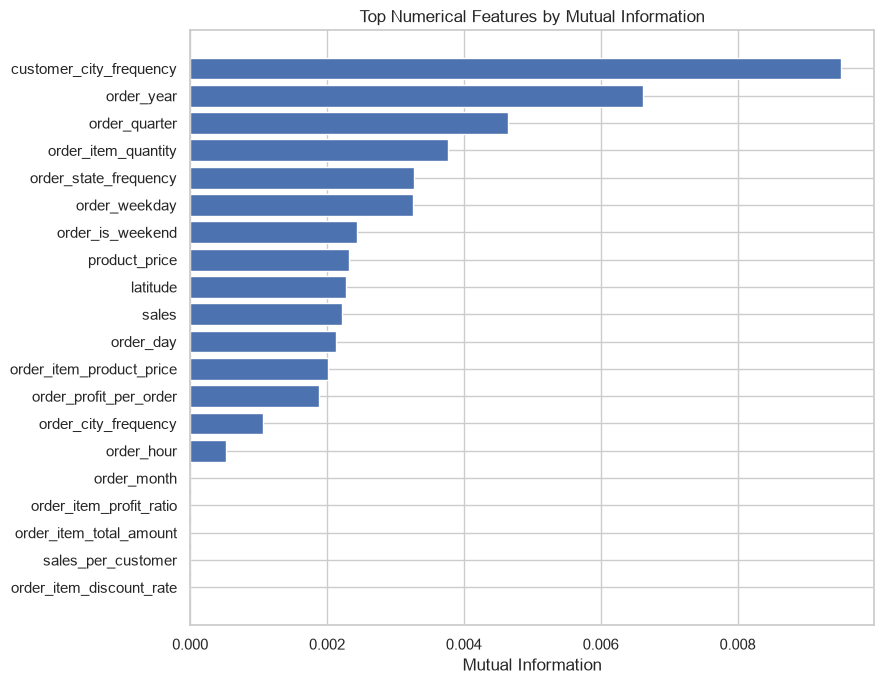

In [19]:
mi = mutual_information_report(
    featured,
    numerical_features,
    TARGET_COLUMN,
)

display(mi)

top_mi = mi.head(20).sort_values("mutual_information")

plt.figure(figsize=(9, 7))
plt.barh(
    top_mi["feature"],
    top_mi["mutual_information"],
)
plt.title("Top Numerical Features by Mutual Information")
plt.xlabel("Mutual Information")
plt.tight_layout()
plt.show()

### Analysis

Mutual information complements Pearson correlation by detecting nonlinear
dependence. It is used here as a diagnostic, not as an automatic production
feature-dropping rule.

## 6. Chi-square analysis for categorical features

In [20]:
chi_square = chi_square_categorical_report(
    featured,
    categorical_features,
    TARGET_COLUMN,
)

chi_square

,feature,chi2,p_value,degrees_of_freedom,significant_at_0_05
0,shipping_mode,34852.148947,0.000000,3,True
1,customer_state,54.427110,0.113547,43,False
2,payment_type,5.054934,0.167818,3,False
3,order_region,27.271105,0.201110,22,False
4,category_name,55.276213,0.249678,49,False
5,department_name,12.071760,0.280283,10,False
6,order_country,168.522941,0.306654,160,False
7,customer_segment,1.845558,0.397413,2,False
8,market,3.752437,0.440545,4,False
9,product_name,115.663869,0.517564,117,False


### Analysis

The chi-square test checks whether a categorical feature and the target appear
statistically independent. Very small p-values suggest an association, but
significance alone does not measure business importance or causal value.

With a dataset this large, even weak effects can become statistically
significant. Feature decisions therefore combine statistics with leakage,
cardinality, and business semantics.

## 7. Delay rate by shipping mode

,count,delay_rate
shipping_mode,,
First Class,23622,1.000000
Second Class,31056,0.792633
Same Day,7959,0.501822
Standard Class,92851,0.403625


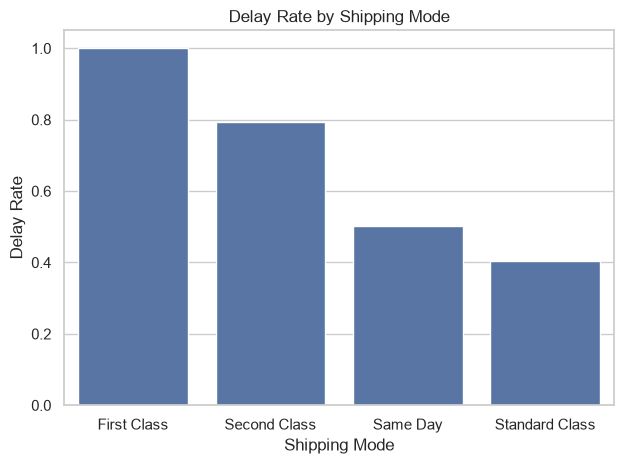

In [21]:
shipping_rate = (
    featured.groupby("shipping_mode", observed=True)[TARGET_COLUMN]
    .agg(["count", "mean"])
    .rename(columns={"mean": "delay_rate"})
    .sort_values("delay_rate", ascending=False)
)

display(shipping_rate)

sns.barplot(
    data=shipping_rate.reset_index(),
    x="shipping_mode",
    y="delay_rate",
)
plt.title("Delay Rate by Shipping Mode")
plt.ylabel("Delay Rate")
plt.xlabel("Shipping Mode")
plt.tight_layout()
plt.show()

### Analysis

Shipping mode displays a strong association with the target in SynDelay. This
is useful predictive information but should be treated carefully because the
synthetic generator may preserve or amplify source-specific operational rules.

**Decision:** retain for V1; monitor distribution and feature importance later.

## 8. Delay rate by product category

,count,delay_rate
category_name,,
Lacrosse,277,0.646209
Crafts,309,0.611650
Women's Clothing,535,0.609346
Books,320,0.606250
Golf Apparel,330,0.603030
Music,377,0.599469
Pet Supplies,364,0.596154
Golf Shoes,361,0.595568
Men's Golf Clubs,280,0.585714


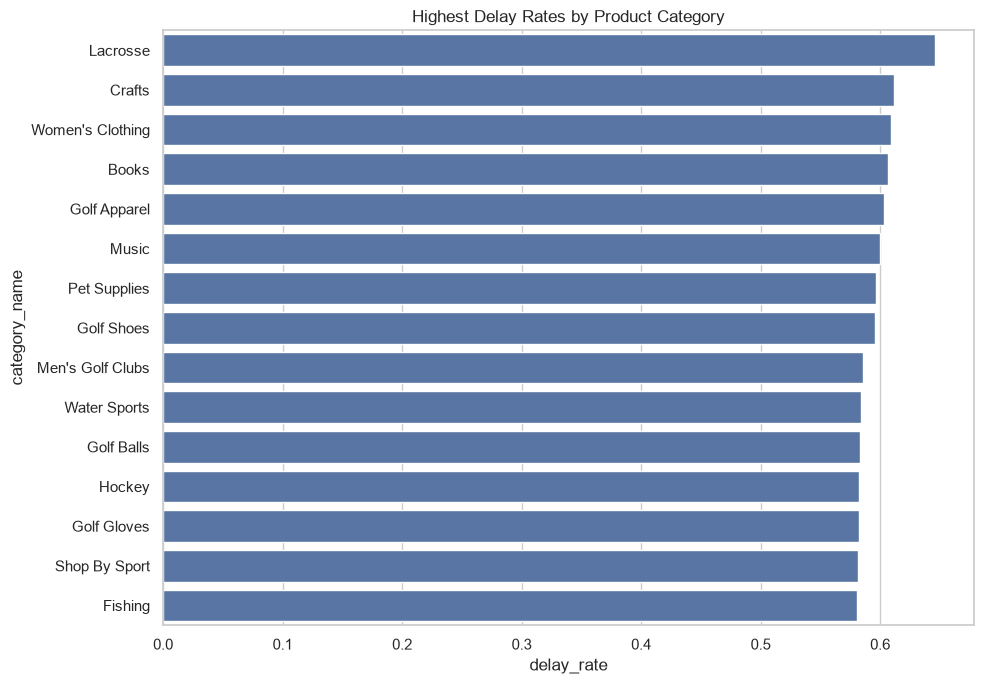

In [22]:
category_rate = (
    featured.groupby("category_name", observed=True)[TARGET_COLUMN]
    .agg(["count", "mean"])
    .rename(columns={"mean": "delay_rate"})
    .query("count >= 250")
    .sort_values("delay_rate", ascending=False)
)

display(category_rate.head(20))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=category_rate.head(15).reset_index(),
    x="delay_rate",
    y="category_name",
)
plt.title("Highest Delay Rates by Product Category")
plt.tight_layout()
plt.show()

### Analysis

Category differences can capture fulfillment complexity, inventory patterns,
or synthetic source relationships. Because category names are low enough in
cardinality to encode safely, they remain candidates for one-hot encoding.

## 9. Delay rate by order weekday

,count,delay_rate,weekday
order_weekday,,,
0,22098,0.573853,Monday
1,21994,0.579022,Tuesday
2,22117,0.578062,Wednesday
3,22402,0.576868,Thursday
4,22553,0.579125,Friday
5,22101,0.573820,Saturday
6,22223,0.577870,Sunday


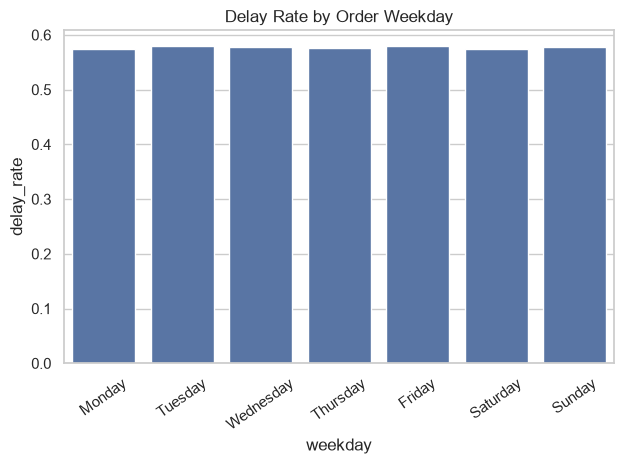

In [23]:
weekday_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}

weekday_rate = (
    featured.groupby("order_weekday", observed=True)[TARGET_COLUMN]
    .agg(["count", "mean"])
    .rename(columns={"mean": "delay_rate"})
)
weekday_rate["weekday"] = weekday_rate.index.map(weekday_names)

display(weekday_rate)

sns.barplot(
    data=weekday_rate.reset_index(),
    x="weekday",
    y="delay_rate",
)
plt.xticks(rotation=35)
plt.title("Delay Rate by Order Weekday")
plt.tight_layout()
plt.show()

### Analysis

Weekday patterns can reflect recurring operational cycles. The feature is safe
because it is derived only from `order_date`, which exists at prediction time.

## 10. Geographic aggregation

,lat_bin,lon_bin,orders,delay_rate
105,18.0,-66.0,56799,0.576912
682,34.0,-118.0,8302,0.581908
1134,41.0,-74.0,5258,0.566755
683,34.0,-117.0,2173,0.594110
1175,42.0,-88.0,1911,0.580324
627,33.0,-117.0,1510,0.573510
1073,40.0,-74.0,1149,0.570931
632,33.0,-112.0,993,0.555891
1131,41.0,-77.0,974,0.572895
853,37.0,-122.0,969,0.573787


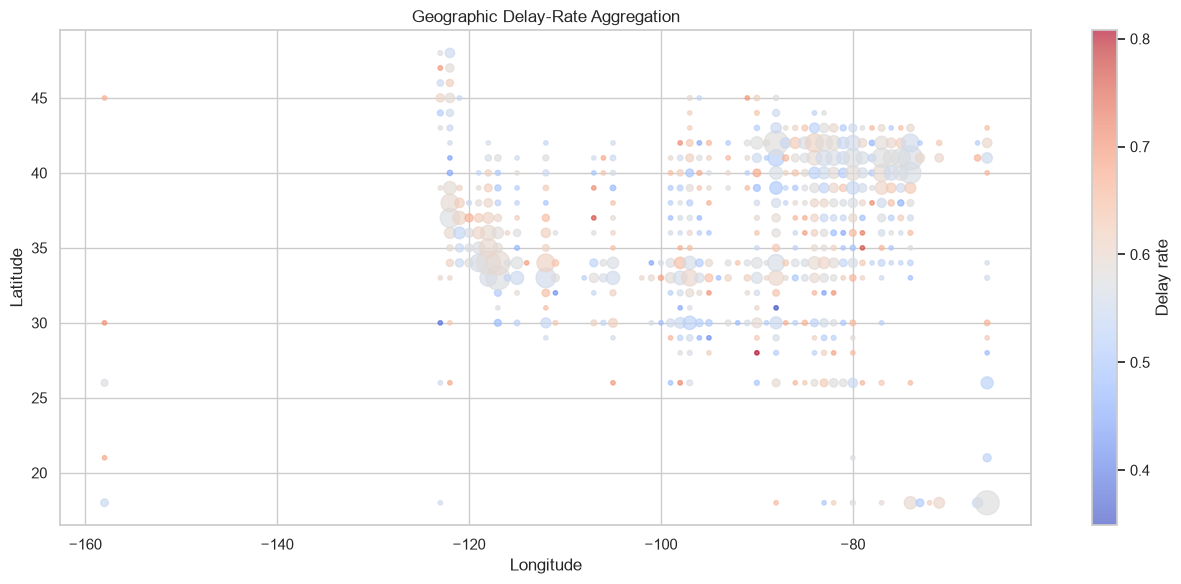

In [24]:
geo_grid = (
    df.assign(
        lat_bin=df["latitude"].round(0),
        lon_bin=df["longitude"].round(0),
    )
    .groupby(["lat_bin", "lon_bin"], observed=True)
    .agg(
        orders=(TARGET_COLUMN, "size"),
        delay_rate=(TARGET_COLUMN, "mean"),
    )
    .reset_index()
    .query("orders >= 25")
)

display(
    geo_grid.sort_values(
        ["orders", "delay_rate"],
        ascending=False,
    ).head(30)
)

plt.figure(figsize=(13, 6))
points = plt.scatter(
    geo_grid["lon_bin"],
    geo_grid["lat_bin"],
    c=geo_grid["delay_rate"],
    s=np.clip(geo_grid["orders"] / 5, 10, 300),
    alpha=0.65,
    cmap="coolwarm",
)
plt.colorbar(points, label="Delay rate")
plt.title("Geographic Delay-Rate Aggregation")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

### Analysis

Spatial aggregation is more reliable than plotting every point because it
reduces visual overplotting. It can reveal geographic pockets with unusual
delay rates.

**Caution:** these coordinates do not represent the full route and should not
be used for causal geographic conclusions.

## 11. EDA conclusions

### Findings to carry into modelling

- The target is suitable for binary classification and does not require
  aggressive rebalancing by default.
- `shipping_mode` is a strong dataset-level predictor and should be retained,
  while monitored for synthetic-data dependence.
- Raw identifiers should not enter the model.
- `shipping_date` and ambiguous post-order status information are excluded
  from the production feature contract.
- High-cardinality geography should use stateful frequency encoding rather
  than one-hot expansion.
- Low/medium-cardinality business categories can use one-hot encoding.
- Chronological evaluation is required because temporal distribution changes
  are relevant to eventual production monitoring.